In [1]:
import sys
import os
import importlib
import warnings
import pickle

from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.utils import shuffle

from catboost import CatBoostClassifier

sys.path.append(".")
from src.cstarters import ml_utils

importlib.reload(ml_utils)

from src.cstarters.ml_utils import avg, load_dataset, featurize_alignment, confusion_matrix_plot, add_stratify_column, drop_labels, average_value_feature, plot_feature_importances, stdev_accuracy

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=".*probability.*deprecated.*"
)

random_seed = 0

In [2]:
data_dir = "../../data"
out_dir = "../../out"

In [3]:
df = load_dataset(path = os.path.join(data_dir, "cstarters_dataset.csv"))

aa_properties = {
    'WOLS870101': [96, 97, 98, 320, 338, 340, 342, 349, 351, 352, 356, 357, 814, 818, 902, 924, 932, 936, 938, 707, 602],
    'WOLS870102': [96, 97, 98, 320, 338, 340, 342, 349, 351, 352, 356, 357, 814, 818, 902, 924, 932, 936, 938, 707, 602],
    'WOLS870103': [96, 97, 98, 320, 338, 340, 342, 349, 351, 352, 356, 357, 814, 818, 902, 924, 932, 936, 938, 707, 602],
    'GRAR740102': [96, 97, 98, 320, 338, 340, 342, 349, 351, 352, 356, 357, 814, 818, 902, 924, 932, 936, 938, 707, 602],
    'RADA880108': [96, 97, 98, 320, 338, 340, 342, 349, 351, 352, 356, 357, 814, 818, 902, 924, 932, 936, 938, 707, 602]
}

df = average_value_feature(
    dataset_df=df,
    positions= [96, 97, 98, 320, 338, 340, 342, 349, 351, 352, 356, 357, 814, 818, 902, 924, 932, 936, 938],
    aa_property="vdwvol",
    output_column="avg_size_tunnel_L",
)

df = average_value_feature(
    dataset_df=df,
    positions=[96, 97, 98, 349, 352, 814, 818, 924, 932, 936, 938, 944],
    aa_property="vdwvol",
    output_column="avg_size_tunnel_S",
)

df = featurize_alignment(df, aa_properties)
ml_df_full = df.drop(columns=["starter_beta_hydroxylation"])
ml_df_full = drop_labels(ml_df_full, 'starter_category', ['AR', 'FA'])
stratify_columns = ['starter_category', 'ncbi_organism_genus']
ml_df_full = add_stratify_column(ml_df_full, stratify_columns)
ml_df_full = ml_df_full.drop(columns=['ncbi_organism_genus'])
ml_df_train, ml_df_test = train_test_split(ml_df_full, test_size = 0.2, stratify = ml_df_full['stratify_column'], random_state = random_seed)

y_train = ml_df_train['starter_category']
X_train = ml_df_train.drop(columns=['cs_accession', 'starter_category', 'stratify_column', ])
X_train, y_train = shuffle(X_train, y_train, random_state=random_seed)

y_test = ml_df_test['starter_category']
X_test = ml_df_test.drop(columns=['cs_accession', 'starter_category', 'stratify_column'])
X_test, y_test = shuffle(X_test, y_test, random_state=random_seed)

y_full = ml_df_full['starter_category']
X_full = ml_df_full.drop(columns=['cs_accession', 'starter_category', 'stratify_column'])
X_full, y_full = shuffle(X_full, y_full, random_state=random_seed)


# Train

[0.85714286 0.61904762 0.66666667 0.47619048 0.45      ] avg: 0.6138095238095238


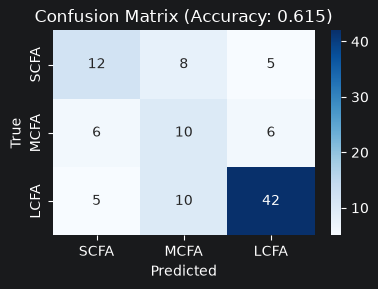

In [4]:
# RF train
rf_params = dict(
    class_weight='balanced',
    ccp_alpha=0.01,
    max_depth=15,
    min_samples_leaf=1,
    max_leaf_nodes=4,
    n_estimators=100,
    min_samples_split=8,
    max_features="log2",
    random_state=random_seed
)

model = RandomForestClassifier(**rf_params)

cv = cross_val_score(model, X_train, y_train, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_train, y_train, cv=5)

confusion_matrix_plot(confusion_matrix(y_train, cv_pred, labels=["SCFA", "MCFA", "LCFA"]), ["SCFA", "MCFA", "LCFA"])

[0.71428571 0.61904762 0.66666667 0.57142857 0.7       ] avg: 0.6542857142857142


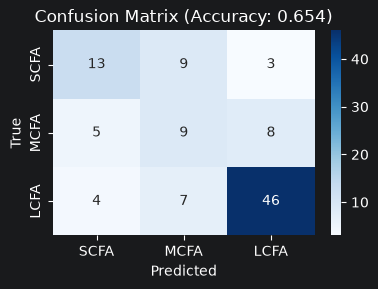

In [5]:
# SVM train
svm_params = dict(
    probability=True,
    C = 0.1, 
    kernel='linear',
    degree=3,
    class_weight='balanced'
)
model = svm.SVC(**svm_params)

cv = cross_val_score(model, X_train, y_train, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_train, y_train, cv=5)

confusion_matrix_plot(confusion_matrix(y_train, cv_pred, labels=["SCFA", "MCFA", "LCFA"]), ["SCFA", "MCFA", "LCFA"])

[0.76190476 0.66666667 0.71428571 0.71428571 0.5       ] avg: 0.6714285714285715


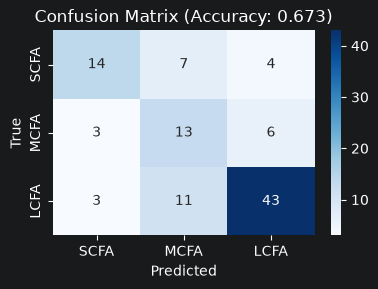

In [6]:
# Logistic Regression train
lr_params = dict(
    solver='newton-cg', 
    class_weight='balanced', 
    # penalty='l2', 
    C=0.01
)
model = LogisticRegression(**lr_params)

cv = cross_val_score(model, X_train, y_train, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_train, y_train, cv=5)

confusion_matrix_plot(confusion_matrix(y_train, cv_pred, labels=["SCFA", "MCFA", "LCFA"]), ["SCFA", "MCFA", "LCFA"])

[0.71428571 0.71428571 0.76190476 0.57142857 0.6       ] avg: 0.6723809523809524


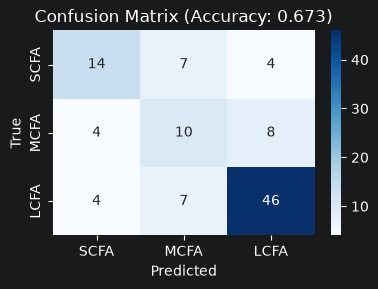

In [7]:
# catboost train
cat_params = dict(
    iterations=175,
    learning_rate=0.2,
    depth=4,
    l2_leaf_reg=3,
    loss_function="MultiClass",
    auto_class_weights="Balanced",
    random_seed=random_seed,
    verbose=0
)

model = CatBoostClassifier(**cat_params)

cv = cross_val_score(model, X_train, y_train, cv=5)
print(cv, "avg:", avg(cv))

cv_pred = cross_val_predict(model, X_train, y_train, cv=5)

confusion_matrix_plot(confusion_matrix(y_train, cv_pred, labels=["SCFA", "MCFA", "LCFA"]),["SCFA", "MCFA", "LCFA"])

# Test

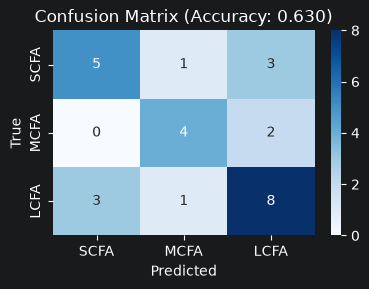

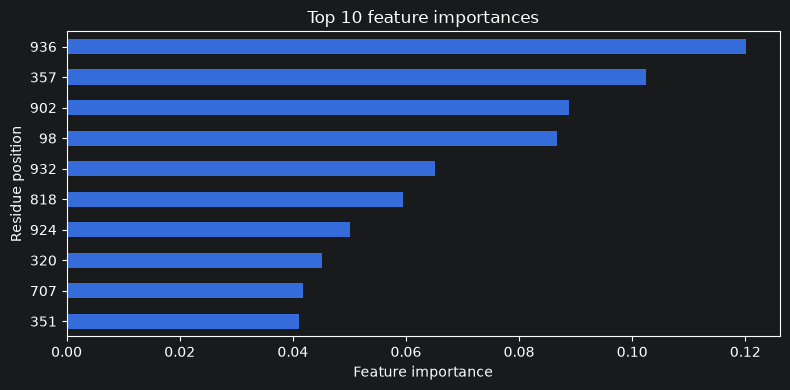

936              0.120124
357              0.102380
902              0.088820
98               0.086709
932              0.065211
818              0.059390
924              0.050125
320              0.045147
707              0.041725
351              0.041020
size_tunnel_S    0.040277
602              0.035455
size_tunnel_L    0.034856
349              0.030960
338              0.030336
96               0.028708
814              0.024006
356              0.020439
352              0.016115
938              0.014191
97               0.009010
342              0.008374
340              0.006623
dtype: float64

In [8]:
# RF test
model = RandomForestClassifier(**rf_params)

model.fit(X_train, y_train)
model_pred = model.predict(X_test)

confusion_matrix_plot(confusion_matrix(y_test, model_pred, labels=["SCFA", "MCFA", "LCFA"]), ["SCFA", "MCFA", "LCFA"])
plot_feature_importances(model, X_test.columns)

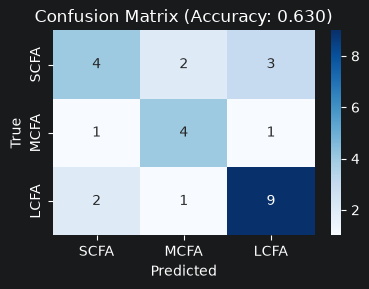

In [9]:
# SVM test
model = svm.SVC(**svm_params)

model.fit(X_train, y_train)
model_pred = model.predict(X_test)

confusion_matrix_plot(confusion_matrix(y_test, model_pred, labels=["SCFA", "MCFA", "LCFA"]), ["SCFA", "MCFA", "LCFA"])

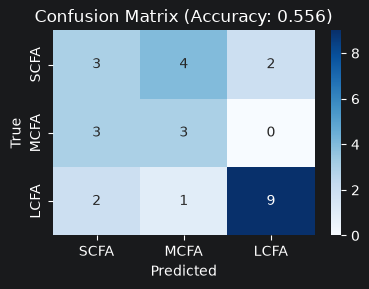

In [10]:
# Logistic Regression test
model = LogisticRegression(**lr_params)

model.fit(X_train, y_train)
model_pred = model.predict(X_test)

confusion_matrix_plot(confusion_matrix(y_test, model_pred, labels=["SCFA", "MCFA", "LCFA"]), ["SCFA", "MCFA", "LCFA"])

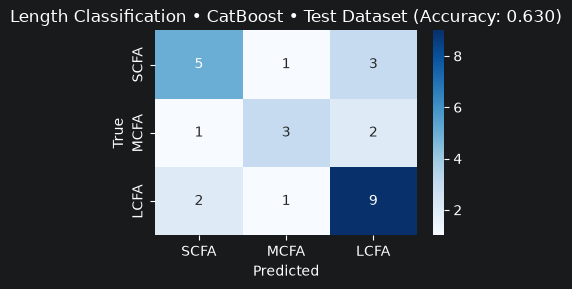

In [11]:
# catboost test
model = CatBoostClassifier(**cat_params)

model.fit(X_train, y_train)
model_pred = model.predict(X_test)

confusion_matrix_plot(confusion_matrix(y_test, model_pred, labels=["SCFA", "MCFA", "LCFA"]), ["SCFA", "MCFA", "LCFA"], title="Length Classification • CatBoost • Test Dataset")

# Full

[0.7037037  0.5        0.73076923 0.57692308 0.65384615] avg: 0.6330484330484331


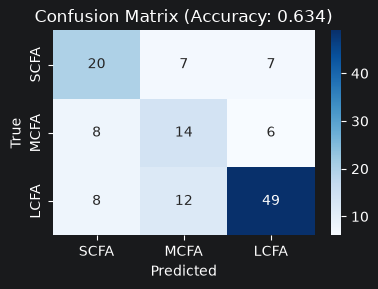

In [12]:
# RF full
model = RandomForestClassifier(**rf_params)

cv = cross_val_score(model, X_full, y_full, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_full, y_full, cv=5)

confusion_matrix_plot(confusion_matrix(y_full, cv_pred, labels=["SCFA", "MCFA", "LCFA"]), ["SCFA", "MCFA", "LCFA"])

[0.77777778 0.53846154 0.61538462 0.57692308 0.73076923] avg: 0.6478632478632479


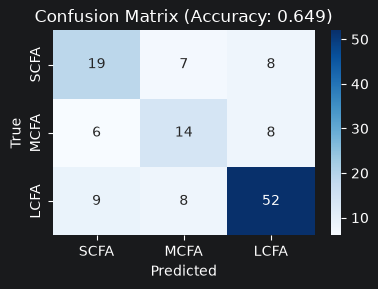

(np.float64(0.6439800569800569), np.float64(0.02520588850740888))

In [13]:
# SVM full
model = svm.SVC(**svm_params)

cv = cross_val_score(model, X_full, y_full, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_full, y_full, cv=5)

confusion_matrix_plot(confusion_matrix(y_full, cv_pred, labels=["SCFA", "MCFA", "LCFA"]), ["SCFA", "MCFA", "LCFA"])
stdev_accuracy(model, X_full, y_full, iterations=100)

[0.77777778 0.61538462 0.69230769 0.57692308 0.69230769] avg: 0.6709401709401709


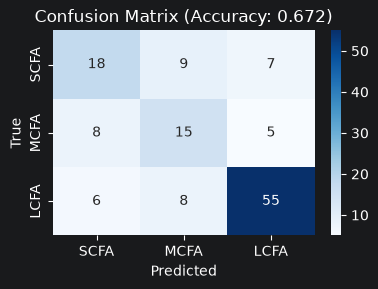

In [14]:
# Logistic Regression full
model = LogisticRegression(**lr_params)

cv = cross_val_score(model, X_full, y_full, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_full, y_full, cv=5)

confusion_matrix_plot(confusion_matrix(y_full, cv_pred, labels=["SCFA", "MCFA", "LCFA"]), ["SCFA", "MCFA", "LCFA"])

[0.7037037  0.53846154 0.61538462 0.61538462 0.80769231] avg: 0.6561253561253562


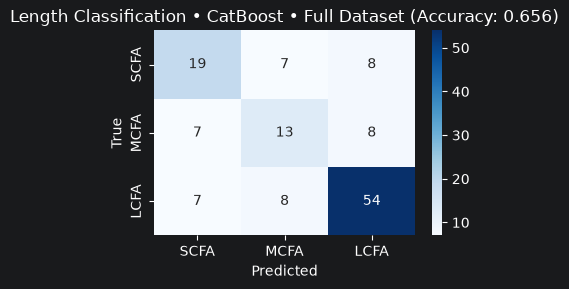

(np.float64(0.6944358974358974), np.float64(0.024562352357516474))

In [15]:
# catboost full
model = CatBoostClassifier(**cat_params)

cv = cross_val_score(model, X_full, y_full, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_full, y_full, cv=5)

confusion_matrix_plot(confusion_matrix(y_full, cv_pred, labels=["SCFA", "MCFA", "LCFA"]), ["SCFA", "MCFA", "LCFA"], title="Length Classification • CatBoost • Full Dataset")

stdev_accuracy(model, X_full, y_full, iterations=100)


In [16]:
model = CatBoostClassifier(**cat_params)

model.fit(X_full, y_full)

pickle.dump(model, open(os.path.join(out_dir, "ml_length.pkl"), "wb"))